**IMPORTI I UČITAVANJE**

In [30]:
!rm -rf clone && git clone https://github.com/pui-sum-rv/lab5 clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 17 (delta 3), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 152.42 KiB | 1.36 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [31]:
import os
print(os.listdir('images/'))

['thresholded_example.png', 'result_example.png', 'thresholded.png', 'distance_transform_example.png', 'result_original.png', 'cells.jpg', 'result.png']


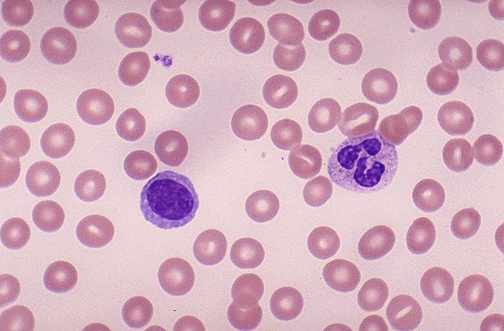

In [32]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import math
from google.colab.patches import cv2_imshow
import random as rng

img = cv.imread('images/cells.jpg')
cv2_imshow(img)

**GRAYSCALE**

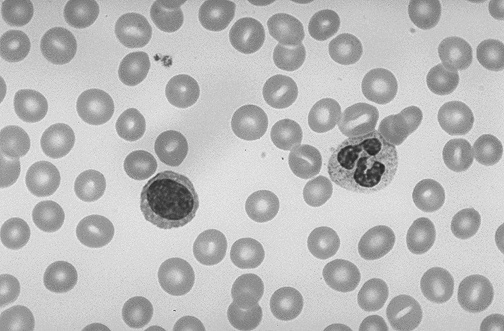

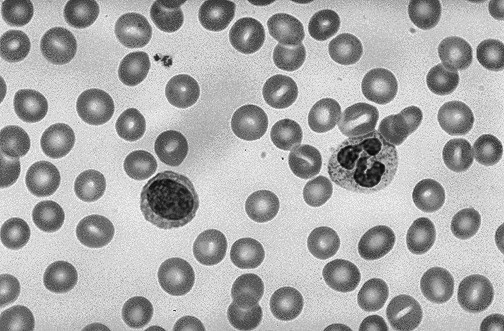

In [33]:
#definicija clahe funkcije
clahe_obj = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
def clahe(img):
    return clahe_obj.apply(img)

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv2_imshow(gray)

gray = clahe(gray)
cv2_imshow(gray)

**OTSU TRESHOLD**

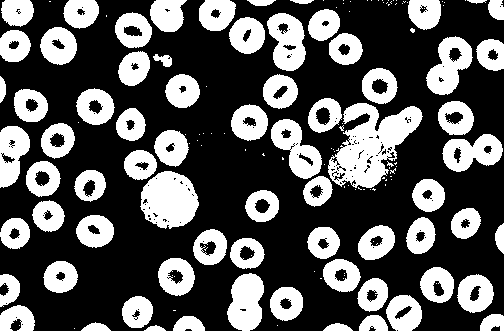

In [34]:
thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
cv.imwrite("images/thresholded.png", thresh[1])
cv2_imshow(thresh[1])

**Morfološke operacije i sure background**

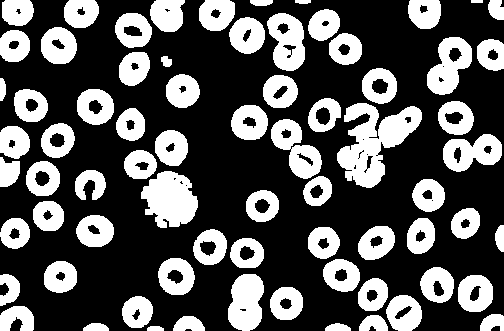

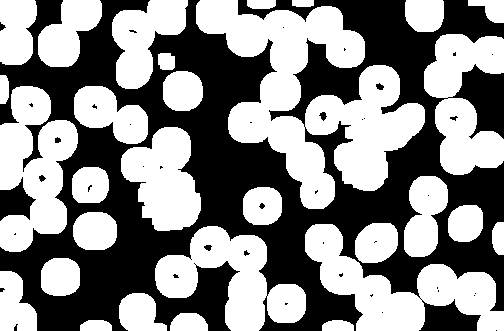

In [35]:
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
opening = cv.morphologyEx(thresh[1], cv.MORPH_OPEN, kernel, iterations=2)
cv2_imshow(opening)

sure_bg = cv.dilate(opening, kernel, iterations=3)
cv2_imshow(sure_bg)

**Distance transform i sure foreground**

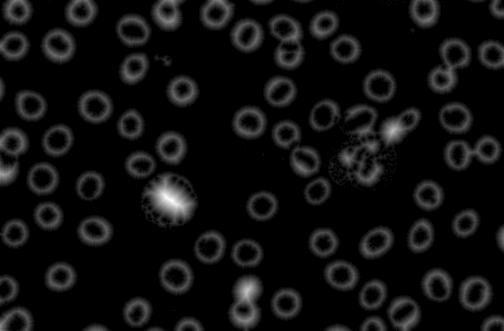

In [36]:
dist_transform = cv.distanceTransform(thresh[1], cv.DIST_L2, 3)
cv.normalize(dist_transform, dist_transform, 0, 1.0, cv.NORM_MINMAX)
cv2_imshow(dist_transform*255)

ret, sure_fg = cv.threshold(dist_transform, 0.2*dist_transform.max(), 255, 0)

**Watershed**

In [37]:
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg, sure_fg)

ret, markers = cv.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0

markers = cv.watershed(img, markers)

**Rezultat**

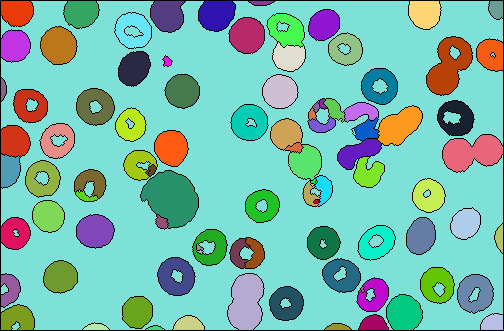

True

In [38]:
colors = []
for i in range(markers.shape[0] * markers.shape[1]):
    colors.append((rng.randint(0,256), rng.randint(0,256), rng.randint(0,256)))

dst = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
for i in range(markers.shape[0]):
    for j in range(markers.shape[1]):
        index = markers[i,j]
        if index > 0:  # preskoči boundary piksele (-1)
            dst[i,j,:] = colors[index-1]

cv2_imshow(dst)
cv.imwrite("images/result.png", dst)

**Usporedbom result.png (s CLAHE) i result_original.png (bez CLAHE) vidljivo je da
result.png ima bolju segmentaciju stanica. CLAHE (Contrast Limited Adaptive Histogram
Equalization) poboljšava lokalni kontrast slike, zbog čega watershed algoritam bolje
prepoznaje granice između stanica. Bez CLAHE neke stanice koje su blizu jedna drugoj
su spojene u jedan segment (undersegmentation), dok s CLAHE te iste stanice su
pravilno odvojene.**